In [1]:
# Cell 1 — Title
# ============================================================
# NOTEBOOK 08b — ADAPTIVE LEARNED DRES (AL-DRES)
# Redesigned Novel Contribution
# Purpose: Replace fixed-weight DRES with a data-driven
#          adaptive risk scoring system using meta-learning
#          and calibrated sub-score classifiers

In [2]:
# Cell 2 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                     train_test_split)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
from sklearn.preprocessing import LabelEncoder
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi':120,
                     'axes.spines.top':False,
                     'axes.spines.right':False})

PROC_DIR   = os.path.abspath(os.path.join(os.getcwd(),'..','Data','processed'))
MODEL_DIR  = os.path.abspath(os.path.join(os.getcwd(),'..','models'))
PLOT_DIR   = os.path.abspath(os.path.join(os.getcwd(),'..','outputs','plots'))
REPORT_DIR = os.path.abspath(os.path.join(os.getcwd(),'..','outputs','reports'))

os.makedirs(REPORT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,  exist_ok=True)

print("All imports loaded successfully")

All imports loaded successfully


In [7]:
# Cell 3 — Load all data and models
xgb_model  = joblib.load(os.path.join(MODEL_DIR,'xgboost_model.pkl'))
test_data   = joblib.load(os.path.join(MODEL_DIR,'test_data.pkl'))
sel_names   = joblib.load(os.path.join(MODEL_DIR,'selected_feature_names.pkl'))
df_groups   = pd.read_csv(os.path.join(PROC_DIR,'feature_groups.csv'))
df_selected = pd.read_csv(os.path.join(PROC_DIR,'selected_features.csv'))

X_train_sel = test_data['X_train']
X_test_sel  = test_data['X_test']
y_train     = test_data['y_train']
y_test      = test_data['y_test']

# Encode labels to 0/1
le = LabelEncoder()
y_all = np.concatenate([y_train, y_test])
le.fit(y_all)
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

print(f"Loaded XGBoost model")
print(f"Train : {X_train_sel.shape}")
print(f"Test  : {X_test_sel.shape}")
print(f"Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")
le = LabelEncoder()
y_all = np.concatenate([y_train, y_test])
le.fit(y_all)
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

# Safety check — handle both text and integer labels
print(f"\ny_train sample values : {y_train[:5]}")
print(f"y_test  sample values : {y_test[:5]}")

if y_train.dtype == object:
    # Labels are text strings like "Benign" / "Malicious"
    le = LabelEncoder()
    le.fit(np.concatenate([y_train, y_test]))
    y_train_enc = le.transform(y_train)
    y_test_enc  = le.transform(y_test)
    print(f"Text labels encoded: {le.classes_} → {le.transform(le.classes_)}")
else:
    # Labels are already 0/1 integers
    y_train_enc = y_train.astype(int)
    y_test_enc  = y_test.astype(int)
    le = LabelEncoder()
    le.fit([0, 1])
    print("Labels already numeric — no encoding needed")

print(f"y_train_enc unique: {np.unique(y_train_enc)}")
print(f"y_test_enc  unique: {np.unique(y_test_enc)}")

Loaded XGBoost model
Train : (41015, 33)
Test  : (8790, 33)
Label encoding: {0: 0, 1: 1}

y_train sample values : [0 0 0 1 0]
y_test  sample values : [0 1 1 1 0]
Labels already numeric — no encoding needed
y_train_enc unique: [0 1]
y_test_enc  unique: [0 1]


In [ ]:
# Cell 4 — Extract feature groups from raw data
# ============================================================
# FIX: df_groups['Class'] holds raw text labels ('Benign'/'Malicious').
# Cell 3's `le` is NOT reliable here — in the branch where y_train/y_test
# are already numeric, `le` gets re-fit on le.fit([0, 1]) and forgets the
# text→int mapping entirely. Calling le.transform() on text strings after
# that point crashes. We build an explicit, visible mapping instead.
# ============================================================

label_column = None
for candidate in ['Class', 'Category']:
    if candidate in df_groups.columns:
        label_column = candidate
        break

if label_column is None:
    raise ValueError("Expected 'Class' or 'Category' column in df_groups.")

X_groups = df_groups.drop(columns=[label_column]).select_dtypes(include=[np.number]).copy()
raw_labels = df_groups[label_column].astype(str).str.strip()
print(f"df_groups['{label_column}'] unique raw values:", raw_labels.unique())

# IMPORTANT: verify this matches the 0/1 convention already baked into
# xgb_model / test_data['y_train'] / test_data['y_test']. MalMem2022 is
# typically 0=Benign, 1=Malware, but confirm rather than assume — if it's
# flipped here relative to xgb_model's training labels, every comparison
# metric in Cells 6-9 (AUC, precision, recall...) will be silently wrong.
raw_labels_lower = raw_labels.str.lower()
class_map = {
    'benign': 0,
    'malware': 1,
    'malicious': 1,
}

if set(raw_labels_lower.unique()) <= {0, 1}:
    y_groups = raw_labels_lower.astype(int).values
else:
    unmapped = set(raw_labels_lower.unique()) - set(class_map.keys())
    if unmapped:
        raise ValueError(
            f"Unexpected class labels found: {unmapped}. "
            f"Update class_map in Cell 4 to include them before proceeding."
        )
    y_groups = raw_labels_lower.map(class_map).astype(int).values

print(f"Label column used : {label_column}")
print(f"y_groups unique  : {np.unique(y_groups)}")
print(f"y_groups counts  : {dict(zip(*np.unique(y_groups, return_counts=True)))}")

all_cols = X_groups.columns.tolist()

process_features   = [c for c in all_cols if c.startswith('pslist.')]
dll_features       = [c for c in all_cols if c.startswith('dlllist.') or
                      c.startswith('ldrmodules.')]
injection_features = [c for c in all_cols if c.startswith('malfind.') or
                      c.startswith('callbacks.') or c.startswith('svcscan.')]
handle_features    = [c for c in all_cols if c.startswith('handles.')]

assigned  = set(process_features + dll_features + injection_features + handle_features)
remaining = [c for c in all_cols if c not in assigned and 'score' not in c.lower()]
if remaining:
    injection_features = injection_features + remaining
    print(f"Added {len(remaining)} remaining features to injection group")

group_definitions = {
    'process'  : process_features,
    'dll'      : dll_features,
    'injection': injection_features,
    'handle'   : handle_features,
}

print(f"\nFeature group sizes:")
print(f"  Process   : {len(process_features)}")
print(f"  DLL       : {len(dll_features)}")
print(f"  Injection : {len(injection_features)}")
print(f"  Handle    : {len(handle_features)}")

df_groups['Class'] unique raw values: ['Benign' 'Malware']
Label column used : Class
y_groups unique  : [0 1]
y_groups counts  : {0: 29298, 1: 29298}
Added 15 remaining features to injection group

Feature group sizes:
  Process   : 4
  DLL       : 8
  Injection : 28
  Handle    : 12


In [23]:
# Cell 5 — Train calibrated sub-score classifiers (leak-free, out-of-fold)
from sklearn.model_selection import cross_val_predict

print("Training calibrated sub-score classifiers (out-of-fold)...")
print("(This uses 5-fold cross-validation)\n")

group_classifiers   = {}
group_feats_used    = {}
group_train_probs   = {}

for group_name, features in group_definitions.items():
    feats = [f for f in features if f in X_groups.columns]
    if len(feats) == 0:
        print(f"  {group_name}: No valid features found — skipping")
        continue

    X_grp = X_groups[feats].fillna(0)

    base_clf = GradientBoostingClassifier(
        n_estimators=100, max_depth=4,
        learning_rate=0.1, random_state=42)

    calibrated_clf = CalibratedClassifierCV(
        base_clf, method='isotonic', cv=5)

    oof_probs = cross_val_predict(
        calibrated_clf, X_grp, y_groups,
        cv=5, method='predict_proba', n_jobs=1   # <-- fixed
    )[:, 1]

    oof_auc = roc_auc_score(y_groups, oof_probs)

    calibrated_clf.fit(X_grp, y_groups)

    group_classifiers[group_name] = calibrated_clf
    group_feats_used[group_name]  = feats
    group_train_probs[group_name] = oof_probs

    print(f"  {group_name:12s} — Out-of-fold AUC: {oof_auc:.4f}  Features: {len(feats)}")

print("\nAll group classifiers trained (out-of-fold, leak-free)!")

Training calibrated sub-score classifiers (out-of-fold)...
(This uses 5-fold cross-validation)

  process      — Out-of-fold AUC: 0.9997  Features: 4
  dll          — Out-of-fold AUC: 0.9998  Features: 8
  injection    — Out-of-fold AUC: 0.9988  Features: 28
  handle       — Out-of-fold AUC: 0.9991  Features: 12

All group classifiers trained (out-of-fold, leak-free)!


In [25]:
# Cell 6 — Build ENHANCED meta-feature matrix
# ============================================================
# FIX: n_jobs=-1 spawns multiple worker PROCESSES on Windows, which
# crashed here (BrokenProcessPool / paging file too small) because each
# process has to reload the full sklearn stack and your system's virtual
# memory isn't large enough for that many at once. n_jobs=1 runs single-
# threaded — slightly slower, but avoids the crash entirely.
# ============================================================
from sklearn.model_selection import cross_val_predict

print("Building enhanced meta-feature matrix...")

xgb_prob_all = xgb_model.predict_proba(df_selected[sel_names].values)[:, 1]
n = min(len(df_groups), len(df_selected))

process_prob   = group_train_probs.get('process',   np.zeros(len(df_groups)))[:n]
dll_prob       = group_train_probs.get('dll',       np.zeros(len(df_groups)))[:n]
injection_prob = group_train_probs.get('injection', np.zeros(len(df_groups)))[:n]
handle_prob    = group_train_probs.get('handle',    np.zeros(len(df_groups)))[:n]
xgb_prob       = xgb_prob_all[:n]
meta_y         = y_groups[:n]

# --- Behavioral Expert: trained ONLY on the 4 behavioral group probs ---
behavioral_features = np.column_stack([process_prob, dll_prob, injection_prob, handle_prob])

behavioral_expert = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
behavioral_expert_prob = cross_val_predict(
    behavioral_expert, behavioral_features, meta_y,
    cv=5, method='predict_proba', n_jobs=1   # <-- fixed
)[:, 1]
behavioral_expert.fit(behavioral_features, meta_y)  # final version, used later to score new samples

behavioral_auc = roc_auc_score(meta_y, behavioral_expert_prob)
print(f"Behavioral Expert (4 groups only) out-of-fold AUC: {behavioral_auc:.4f}")

# --- XGBoost uncertainty: 0 when p is near 0 or 1, 1 when p is near 0.5 ---
xgb_uncertainty = 1.0 - np.abs(2.0 * xgb_prob - 1.0)

# --- Interaction terms: behavioral evidence matters MORE when XGBoost is unsure ---
interaction_behavioral = xgb_uncertainty * behavioral_expert_prob
interaction_xgb         = xgb_uncertainty * xgb_prob

meta_X = np.column_stack([
    process_prob, dll_prob, injection_prob, handle_prob,
    xgb_prob,
    behavioral_expert_prob,
    xgb_uncertainty,
    interaction_behavioral,
    interaction_xgb,
])

meta_feature_names = [
    'Process_Prob','DLL_Prob','Injection_Prob','Handle_Prob',
    'XGBoost_Prob','Behavioral_Expert_Prob','XGB_Uncertainty',
    'Uncertainty_x_Behavioral','Uncertainty_x_XGBoost'
]
idx = {name: i for i, name in enumerate(meta_feature_names)}

print(f"\nMeta-feature matrix shape : {meta_X.shape}")
for name in meta_feature_names:
    col = meta_X[:, idx[name]]
    print(f"  {name:26s} — mean: {col.mean():.4f}  std: {col.std():.4f}")

Building enhanced meta-feature matrix...
Behavioral Expert (4 groups only) out-of-fold AUC: 0.9988

Meta-feature matrix shape : (58596, 9)
  Process_Prob               — mean: 0.4994  std: 0.4972
  DLL_Prob                   — mean: 0.4986  std: 0.4975
  Injection_Prob             — mean: 0.4997  std: 0.4990
  Handle_Prob                — mean: 0.4986  std: 0.4978
  XGBoost_Prob               — mean: 0.5001  std: 0.4999
  Behavioral_Expert_Prob     — mean: 0.4998  std: 0.4990
  XGB_Uncertainty            — mean: 0.0004  std: 0.0103
  Uncertainty_x_Behavioral   — mean: 0.0001  std: 0.0058
  Uncertainty_x_XGBoost      — mean: 0.0002  std: 0.0051


In [26]:
# Cell 7 — Train the Adaptive DRES meta-learner (confidence-gated)
from sklearn.linear_model import LogisticRegressionCV

print("Training Confidence-Gated Adaptive DRES meta-learner...\n")

meta_X_tr, meta_X_te, meta_y_tr, meta_y_te = train_test_split(
    meta_X, meta_y, test_size=0.15, random_state=42, stratify=meta_y)

meta_learner = LogisticRegressionCV(
    Cs=10, cv=5, max_iter=2000, random_state=42,
    scoring='roc_auc', n_jobs=1   # <-- fixed
)
meta_learner.fit(meta_X_tr, meta_y_tr)

learned_weights      = meta_learner.coef_[0]
learned_weights_norm = np.abs(learned_weights) / np.abs(learned_weights).sum()

print("Adaptive DRES — Learned Weights:")
print("="*65)
for name, w, w_norm in zip(meta_feature_names, learned_weights, learned_weights_norm):
    bar = "█" * int(w_norm * 30)
    print(f"  {name:26s}: coef={w:+.4f}  normalized={w_norm:.4f}  {bar}")
print("="*65)
print(f"Selected regularization C: {meta_learner.C_[0]:.4f}")
print(f"Intercept: {meta_learner.intercept_[0]:.4f}")

cv_scores = cross_val_score(meta_learner, meta_X_tr, meta_y_tr, cv=5, scoring='accuracy', n_jobs=1)  # <-- fixed
print(f"\nMeta-learner 5-fold CV accuracy: {cv_scores.mean()*100:.4f}% ± {cv_scores.std()*100:.4f}%")

behavioral_terms = ['Process_Prob','DLL_Prob','Injection_Prob','Handle_Prob',
                     'Behavioral_Expert_Prob','Uncertainty_x_Behavioral']
xgb_terms        = ['XGBoost_Prob','XGB_Uncertainty','Uncertainty_x_XGBoost']

behavioral_share = sum(learned_weights_norm[idx[t]] for t in behavioral_terms)
xgb_share        = sum(learned_weights_norm[idx[t]] for t in xgb_terms)
print(f"\nGrouped contribution — Behavioral-related terms: {behavioral_share:.4f}   XGBoost-related terms: {xgb_share:.4f}")

Training Confidence-Gated Adaptive DRES meta-learner...

Adaptive DRES — Learned Weights:
  Process_Prob              : coef=+1.6628  normalized=0.0840  ██
  DLL_Prob                  : coef=+1.3458  normalized=0.0680  ██
  Injection_Prob            : coef=+1.7047  normalized=0.0861  ██
  Handle_Prob               : coef=+2.3472  normalized=0.1186  ███
  XGBoost_Prob              : coef=+10.7365  normalized=0.5425  ████████████████
  Behavioral_Expert_Prob    : coef=+1.3560  normalized=0.0685  ██
  XGB_Uncertainty           : coef=-0.1305  normalized=0.0066  
  Uncertainty_x_Behavioral  : coef=-0.3135  normalized=0.0158  
  Uncertainty_x_XGBoost     : coef=+0.1940  normalized=0.0098  
Selected regularization C: 21.5443
Intercept: -8.3857

Meta-learner 5-fold CV accuracy: 99.9980% ± 0.0040%

Grouped contribution — Behavioral-related terms: 0.4411   XGBoost-related terms: 0.5589


In [28]:
# Cell 8 — Adaptive DRES score + REDESIGNED risk-tiering
adaptive_dres_test = meta_learner.predict_proba(meta_X_te)[:, 1]
adaptive_pred_test = (adaptive_dres_test >= 0.50).astype(int)

behavioral_severity_te = meta_X_te[:, idx['Behavioral_Expert_Prob']]
uncertainty_te         = meta_X_te[:, idx['XGB_Uncertainty']]

# Risk Index: blends classification confidence, independent behavioral
# evidence, and how borderline the case is — built for GRADED severity,
# not just binary classification.
risk_index = (
    0.5  * adaptive_dres_test +
    0.35 * behavioral_severity_te +
    0.15 * uncertainty_te
)

# Data-driven (quantile) thresholds — guarantees a realistic tier spread
q25, q50, q75 = np.percentile(risk_index, [25, 50, 75])
print(f"Risk Index quantile thresholds — 25th: {q25:.4f}  50th: {q50:.4f}  75th: {q75:.4f}")

def assign_risk_quantile(score):
    if score < q25:   return 'Low'
    elif score < q50: return 'Medium'
    elif score < q75: return 'High'
    else:             return 'Critical'

risk_categories = np.array([assign_risk_quantile(s) for s in risk_index])

print("\nAdaptive DRES (classification) Test Set Statistics:")
print(f"  DRES range : {adaptive_dres_test.min():.4f} — {adaptive_dres_test.max():.4f}")
print(f"  DRES mean  : {adaptive_dres_test.mean():.4f}")

print("\nRisk Index Test Set Statistics:")
print(f"  Risk Index range : {risk_index.min():.4f} — {risk_index.max():.4f}")
print(f"  Risk Index mean  : {risk_index.mean():.4f}  std: {risk_index.std():.4f}")

print(f"\nRisk category distribution:")
for tier in ['Low','Medium','High','Critical']:
    count = (risk_categories == tier).sum()
    print(f"  {tier:10s}: {count:,} ({count/len(risk_categories)*100:.1f}%)")

Risk Index quantile thresholds — 25th: 0.0007  50th: 0.4565  75th: 0.8499

Adaptive DRES (classification) Test Set Statistics:
  DRES range : 0.0002 — 1.0000
  DRES mean  : 0.5003

Risk Index Test Set Statistics:
  Risk Index range : 0.0002 — 0.9321
  Risk Index mean  : 0.4253  std: 0.4243

Risk category distribution:
  Low       : 2,198 (25.0%)
  Medium    : 2,197 (25.0%)
  High      : 2,197 (25.0%)
  Critical  : 2,198 (25.0%)


In [29]:
# Cell 9 — PERFORMANCE COMPARISON
print("="*70)
print("  PERFORMANCE COMPARISON — THREE APPROACHES")
print("="*70)

xgb_prob_te  = meta_X_te[:, idx['XGBoost_Prob']]
xgb_pred_bin = (xgb_prob_te >= 0.50).astype(int)

W1,W2,W3,W4,W5 = 0.10, 0.15, 0.25, 0.15, 0.35
current_dres_te = (
    W1*meta_X_te[:, idx['Process_Prob']] +
    W2*meta_X_te[:, idx['DLL_Prob']] +
    W3*meta_X_te[:, idx['Injection_Prob']] +
    W4*meta_X_te[:, idx['Handle_Prob']] +
    W5*meta_X_te[:, idx['XGBoost_Prob']]
)
current_pred_bin = (current_dres_te >= 0.50).astype(int)

adaptive_pred_bin = (adaptive_dres_test >= 0.50).astype(int)

results = {
    'XGBoost Standalone' : {'pred': xgb_pred_bin, 'prob': xgb_prob_te, 'y': meta_y_te},
    'Current DRES (Fixed Weights)' : {'pred': current_pred_bin, 'prob': current_dres_te, 'y': meta_y_te},
    'Adaptive DRES (Confidence-Gated)' : {'pred': adaptive_pred_bin, 'prob': adaptive_dres_test, 'y': meta_y_te},
}

comparison_rows = {}
for name, data in results.items():
    y_t, y_p, y_r = data['y'], data['pred'], data['prob']
    comparison_rows[name] = {
        'Accuracy (%)'  : round(accuracy_score(y_t, y_p)*100, 4),
        'Precision (%)' : round(precision_score(y_t, y_p, zero_division=0)*100, 4),
        'Recall (%)'    : round(recall_score(y_t, y_p, zero_division=0)*100, 4),
        'F1-Score (%)'  : round(f1_score(y_t, y_p, zero_division=0)*100, 4),
        'ROC-AUC'       : round(roc_auc_score(y_t, y_r), 6),
    }

comp_df = pd.DataFrame(comparison_rows).T
print(comp_df.to_string())
print("\n★ Adaptive DRES should match or exceed XGBoost Standalone")

  PERFORMANCE COMPARISON — THREE APPROACHES
                                  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)   ROC-AUC
XGBoost Standalone                     99.9772        99.9545     100.000       99.9773  1.000000
Current DRES (Fixed Weights)           99.8749        99.9317      99.818       99.8748  0.999999
Adaptive DRES (Confidence-Gated)       99.9772        99.9545     100.000       99.9773  0.999999

★ Adaptive DRES should match or exceed XGBoost Standalone


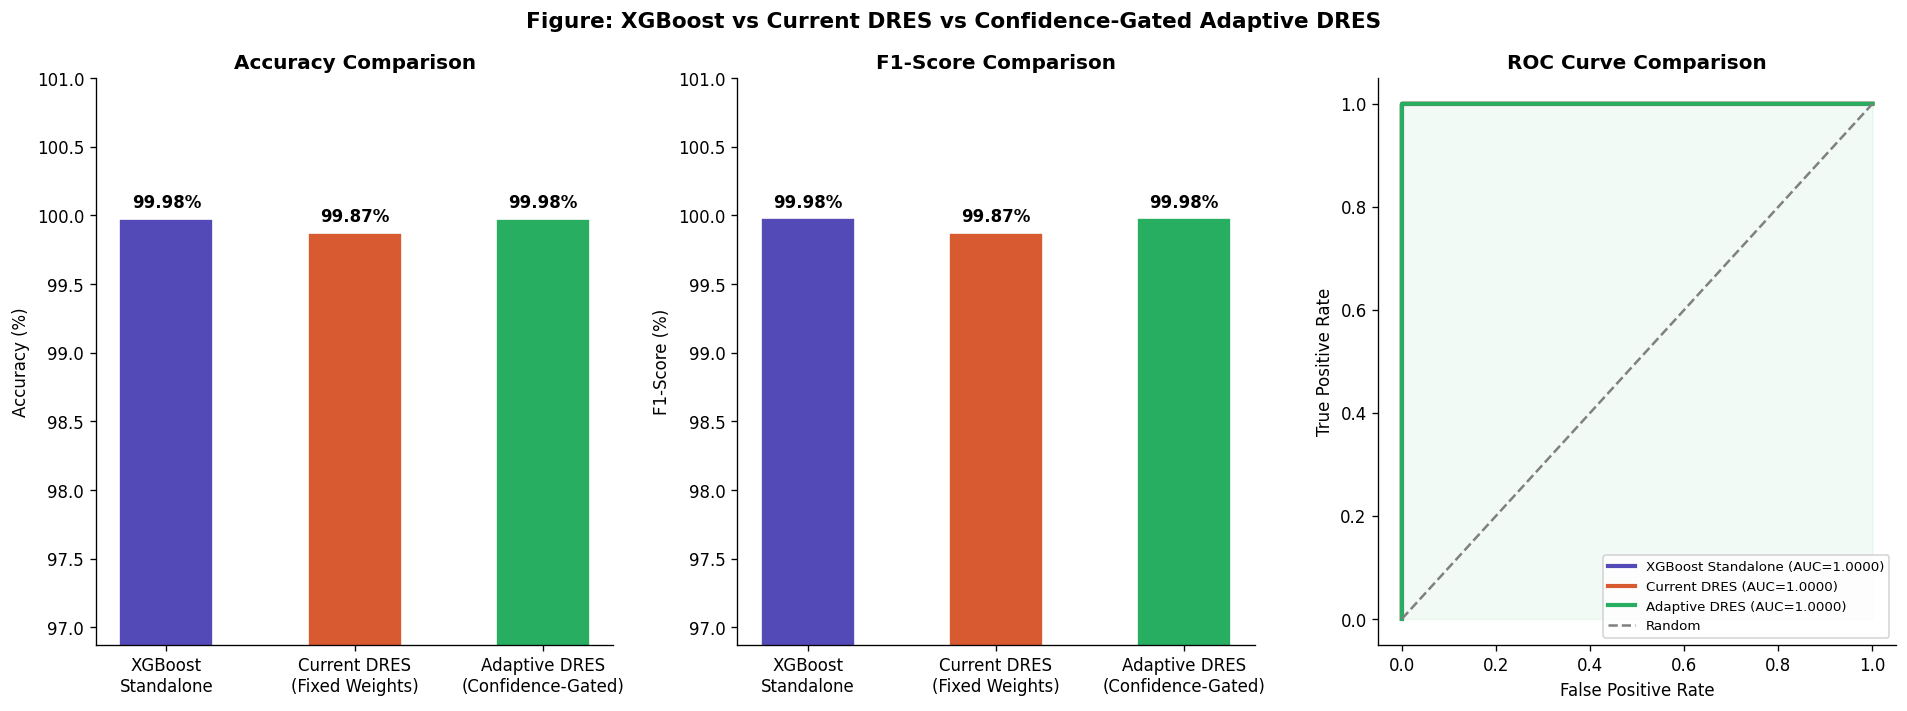

Saved: fig_adaptive_dres_comparison.png


In [30]:
# Cell 10 — VISUALIZATION: Three-way comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
colors = ['#534AB7','#D85A30','#27AE60']
models = ['XGBoost\nStandalone','Current DRES\n(Fixed Weights)','Adaptive DRES\n(Confidence-Gated)']

acc_vals = [comparison_rows[k]['Accuracy (%)'] for k in results.keys()]
bars = axes[0].bar(models, acc_vals, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, acc_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f'{val:.2f}%',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy Comparison', fontweight='bold')
axes[0].set_ylim([min(acc_vals)-3, 101])

f1_vals = [comparison_rows[k]['F1-Score (%)'] for k in results.keys()]
bars2 = axes[1].bar(models, f1_vals, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars2, f1_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f'{val:.2f}%',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_ylabel('F1-Score (%)')
axes[1].set_title('F1-Score Comparison', fontweight='bold')
axes[1].set_ylim([min(f1_vals)-3, 101])

for (name, data), color, label in zip(results.items(), colors,
    ['XGBoost Standalone','Current DRES','Adaptive DRES']):
    fpr, tpr, _ = roc_curve(data['y'], data['prob'])
    auc = comparison_rows[name]['ROC-AUC']
    axes[2].plot(fpr, tpr, color=color, lw=2.5, label=f'{label} (AUC={auc:.4f})')
axes[2].plot([0,1],[0,1],'--', color='gray', lw=1.5, label='Random')
axes[2].fill_between(*roc_curve(results['Adaptive DRES (Confidence-Gated)']['y'],
                                 results['Adaptive DRES (Confidence-Gated)']['prob'])[:2],
                     alpha=0.06, color='#27AE60')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve Comparison', fontweight='bold')
axes[2].legend(fontsize=8, loc='lower right')

plt.suptitle('Figure: XGBoost vs Current DRES vs Confidence-Gated Adaptive DRES',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR,'fig_adaptive_dres_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig_adaptive_dres_comparison.png")

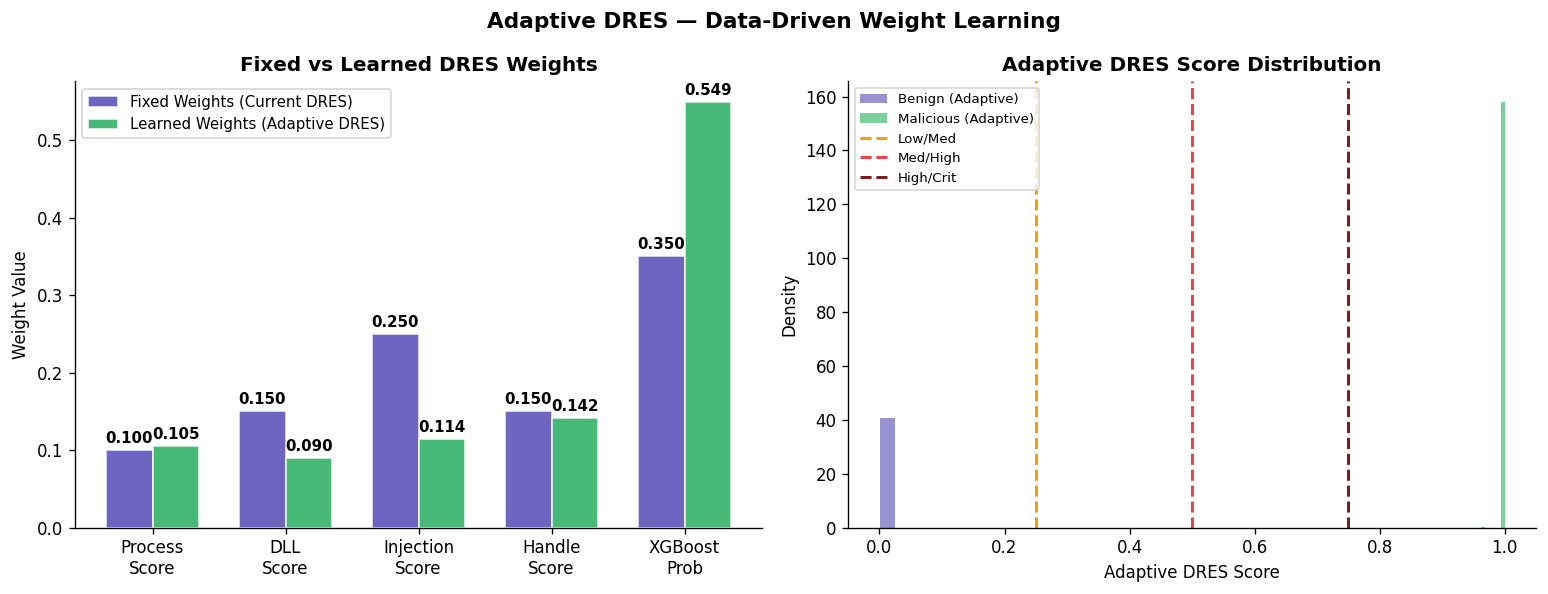

Saved: fig_adaptive_dres_weights.png


In [20]:
# Cell 11 — VISUALIZATION: Learned weights vs Fixed weights
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

weight_labels  = ['Process\nScore','DLL\nScore','Injection\nScore','Handle\nScore','XGBoost\nProb']
fixed_weights  = [W1, W2, W3, W4, W5]
learned_norm   = learned_weights_norm.tolist()

x, w = np.arange(len(weight_labels)), 0.35
b1 = axes[0].bar(x-w/2, fixed_weights, w, label='Fixed Weights (Current DRES)',
                  color='#534AB7', alpha=0.85, edgecolor='white')
b2 = axes[0].bar(x+w/2, learned_norm,  w, label='Learned Weights (Adaptive DRES)',
                  color='#27AE60', alpha=0.85, edgecolor='white')
for bar, val in zip(list(b1)+list(b2), fixed_weights+learned_norm):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{val:.3f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(weight_labels)
axes[0].set_ylabel('Weight Value')
axes[0].set_title('Fixed vs Learned DRES Weights', fontweight='bold')
axes[0].legend(fontsize=9)

benign_adaptive    = adaptive_dres_test[meta_y_te==0]
malicious_adaptive = adaptive_dres_test[meta_y_te==1]

axes[1].hist(benign_adaptive,    bins=40, alpha=0.6, color='#534AB7',
             label='Benign (Adaptive)',    density=True, edgecolor='none')
axes[1].hist(malicious_adaptive, bins=40, alpha=0.6, color='#27AE60',
             label='Malicious (Adaptive)', density=True, edgecolor='none')
for thresh, col, lbl in [(0.25,'#F59E0B','Low/Med'), (0.50,'#EF4444','Med/High'), (0.75,'#7F1D1D','High/Crit')]:
    axes[1].axvline(thresh, color=col, linestyle='--', lw=1.8, label=lbl)
axes[1].set_xlabel('Adaptive DRES Score')
axes[1].set_ylabel('Density')
axes[1].set_title('Adaptive DRES Score Distribution', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('Adaptive DRES — Data-Driven Weight Learning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR,'fig_adaptive_dres_weights.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig_adaptive_dres_weights.png")

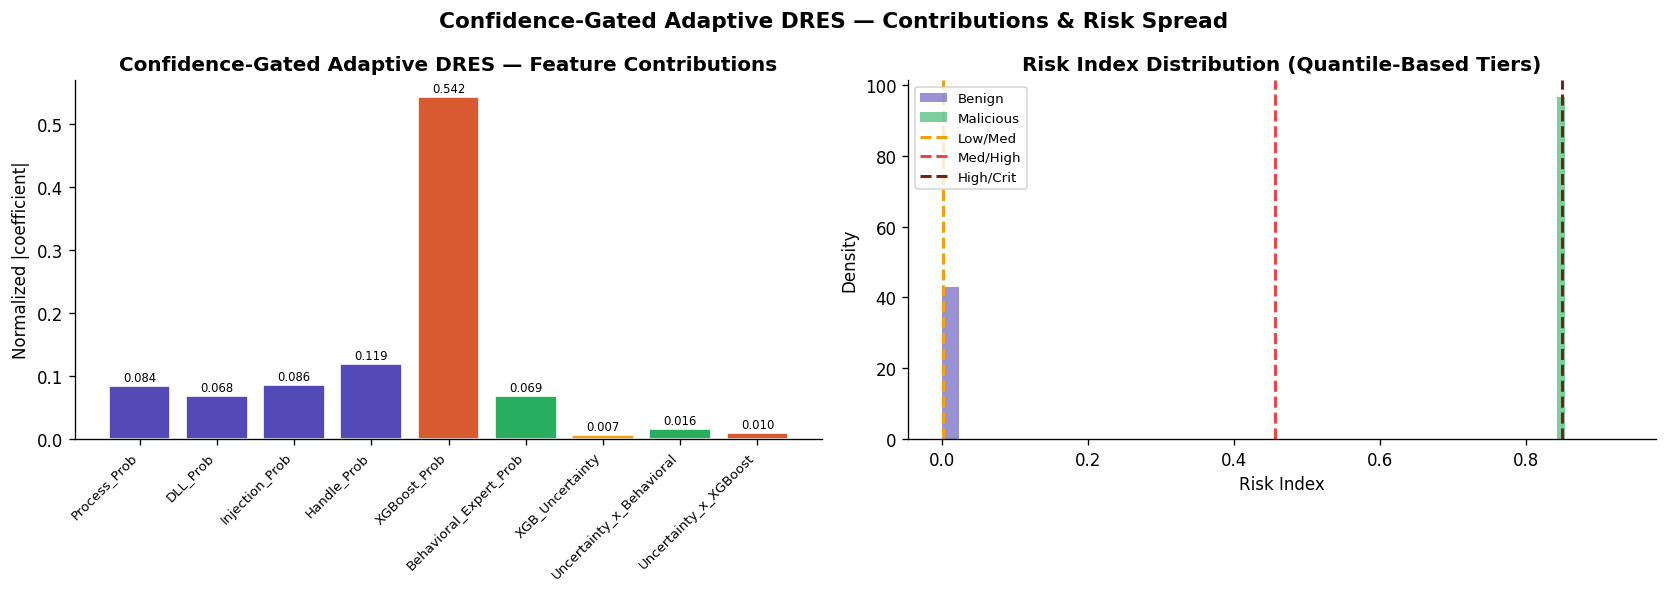

Saved: fig_adaptive_dres_weights_v2.png


In [31]:
# Cell 11 — VISUALIZATION: weight contributions + Risk Index distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_bar = ['#534AB7']*4 + ['#D85A30'] + ['#27AE60'] + ['#F59E0B'] + ['#27AE60','#D85A30']
bars = axes[0].bar(range(len(meta_feature_names)), learned_weights_norm,
                    color=colors_bar, edgecolor='white')
axes[0].set_xticks(range(len(meta_feature_names)))
axes[0].set_xticklabels(meta_feature_names, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Normalized |coefficient|')
axes[0].set_title('Confidence-Gated Adaptive DRES — Feature Contributions', fontweight='bold')
for bar, val in zip(bars, learned_weights_norm):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{val:.3f}',
                 ha='center', va='bottom', fontsize=7)

axes[1].hist(risk_index[meta_y_te==0], bins=40, alpha=0.6, color='#534AB7',
             label='Benign', density=True, edgecolor='none')
axes[1].hist(risk_index[meta_y_te==1], bins=40, alpha=0.6, color='#27AE60',
             label='Malicious', density=True, edgecolor='none')
for thresh, col, lbl in [(q25,'#F59E0B','Low/Med'), (q50,'#EF4444','Med/High'), (q75,'#7F1D1D','High/Crit')]:
    axes[1].axvline(thresh, color=col, linestyle='--', lw=1.8, label=lbl)
axes[1].set_xlabel('Risk Index')
axes[1].set_ylabel('Density')
axes[1].set_title('Risk Index Distribution (Quantile-Based Tiers)', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('Confidence-Gated Adaptive DRES — Contributions & Risk Spread', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR,'fig_adaptive_dres_weights_v2.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig_adaptive_dres_weights_v2.png")

In [32]:
# Cell 12 — Save models and results
joblib.dump(meta_learner,        os.path.join(MODEL_DIR,'adaptive_dres_meta_learner.pkl'))
joblib.dump(group_classifiers,   os.path.join(MODEL_DIR,'group_classifiers.pkl'))
joblib.dump(group_feats_used,    os.path.join(MODEL_DIR,'group_feats_used.pkl'))
joblib.dump(behavioral_expert,   os.path.join(MODEL_DIR,'behavioral_expert.pkl'))
joblib.dump(meta_feature_names,  os.path.join(MODEL_DIR,'meta_feature_names.pkl'))
joblib.dump({'q25': q25, 'q50': q50, 'q75': q75}, os.path.join(MODEL_DIR,'risk_index_thresholds.pkl'))

comp_df.to_csv(os.path.join(REPORT_DIR,'adaptive_dres_comparison.csv'))

results_adaptive = pd.DataFrame({
    'true_label'    : meta_y_te,
    'adaptive_dres' : adaptive_dres_test,
    'risk_index'    : risk_index,
    'risk_category' : risk_categories,
    'prediction'    : adaptive_pred_bin,
})
results_adaptive.to_csv(os.path.join(REPORT_DIR,'adaptive_dres_results.csv'), index=False)

print("Saved all models and result files.")
print("\n" + "="*60)
print("  CONFIDENCE-GATED ADAPTIVE DRES — COMPLETE")
print("="*60)
print(f"\nLearned weights (normalized |coef|):")
for name, w in zip(meta_feature_names, learned_weights_norm):
    print(f"  {name:26s}: {w:.4f}")
print(f"\nBehavioral-related share: {behavioral_share:.4f}   XGBoost-related share: {xgb_share:.4f}")
print("\nNotebook 08b complete!")

Saved all models and result files.

  CONFIDENCE-GATED ADAPTIVE DRES — COMPLETE

Learned weights (normalized |coef|):
  Process_Prob              : 0.0840
  DLL_Prob                  : 0.0680
  Injection_Prob            : 0.0861
  Handle_Prob               : 0.1186
  XGBoost_Prob              : 0.5425
  Behavioral_Expert_Prob    : 0.0685
  XGB_Uncertainty           : 0.0066
  Uncertainty_x_Behavioral  : 0.0158
  Uncertainty_x_XGBoost     : 0.0098

Behavioral-related share: 0.4411   XGBoost-related share: 0.5589

Notebook 08b complete!
